# K-NN Algorithm on Breast Cancer Wisconsin Diagonostic

In [1]:
import numpy as np
from collections import Counter

'''
k-NN Classification Algorithim

X_train: input-attribute values of training data
y_train: corresponding vector of outuput-attribute values of training data
X_test: represent single test record
y_test: true output-attribute value of the test record
k: number of nearest neighbors to consider
distance_func: k-NN's distance measure (floating point)
output: majority class among the k nearest neighbors

'''

def knn_predict(X_train, y_train, X_test, k, distance_func):
    distances = [distance_func(X_test, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_nearest_labels = [y_train[i] for i in k_indices]
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

    

## Distance Measures for high dimensionality

In [2]:
'''
Euclidean Distance Function for n-dimensional data points

point1: first n-dimensional data point
point2: second n-dimensional data point
output: Euclidean distance between point1 and point2
'''

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))


'''
Manhattan Distance Function for n-dimensional data points

point1: first n-dimensional data point
point2: second n-dimensional data point
output: Manhattan distance between point1 and point2
'''

def manhattan_distance(point1, point2):
    return np.sum(np.abs(point1 - point2))

'''
Distance Metric Selector Function
p: parameter to choose distance metric (1 for Manhattan, 2 for Euclidean)
'''

def calculate_distance(p=1):
    match p:
        case 1:
            return manhattan_distance
        case 2:
            return euclidean_distance
        case _:
            raise ValueError("Unsupported distance metric. Use 1 for Manhattan or 2 for Euclidean.")

## Seperating Training and Test Data

### Cleaning up data

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = "data.csv"

# Load dataset
df = pd.read_csv(file_path)

# Separating Labels
mean_cols = [col for col in df.columns if col.endswith('_mean')]
se_cols = [col for col in df.columns if col.endswith('_se')]
worst_cols = [col for col in df.columns if col.endswith('_worst')]

# DataFrames
df_mean = df[mean_cols]
df_se = df[se_cols]
df_worst = df[worst_cols]
df_all = df[mean_cols + se_cols + worst_cols]
df_labels = df['diagnosis']


# Splitting Data Sets into Training and Testing Sets

## Mean Features
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(
    df_mean.values,
    df_labels.values, 
    test_size=0.2, 
    random_state=42)

## SE Features
X_train_se, X_test_se, y_train_se, y_test_se = train_test_split(
    df_se.values,
    df_labels.values, 
    test_size=0.2, 
    random_state=42)

## Worst Features
X_train_worst, X_test_worst, y_train_worst, y_test_worst = train_test_split(
    df_worst.values,
    df_labels.values, 
    test_size=0.2, 
    random_state=42)

## All Features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    df_all.values,
    df_labels.values, 
    test_size=0.2, 
    random_state=42)


## Finding Best K-values Algo

In [4]:
import time
'''
Find Best k Value Function
X_train: input-attribute values of training data
y_train: corresponding vector of outuput-attribute values of training data
X_test: input-attribute values of testing data
y_test: corresponding vector of outuput-attribute values of testing data
distance_func: k-NN's distance measure (floating point)
k_values: list of k values to evaluate
'''
def find_best_k(X_train, y_train, X_test, y_test, distance_func, k_values):
    results = []
    k_times = []
    best_k = k_values[0]
    best_accuracy = 0.0
    
    positive = "M"

    for k in k_values:
        start = time.time()
        
        correct_predictions = 0
        TP = TN = FP = FN = 0
        for i in range(len(X_test)):
            
            y_pred = knn_predict(X_train, y_train, X_test[i], k, distance_func)
            true = y_test[i]
            
            # accuracy counter
            if y_pred == true:
                correct_predictions += 1
                
            # precision and recall counters
            if y_pred == positive and true == positive:
                TP += 1
            elif y_pred == positive and true != positive:
                FP += 1
            elif y_pred != positive and true == positive:
                FN += 1
            elif true == positive and y_pred != positive:
                TN += 1
                
        accuracy = correct_predictions / len(X_test)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        results.append({"k": k, "accuracy": accuracy, "precision": precision, "recall": recall})
    
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            
        end = time.time()
        k_times.append(end - start)
            
    results_df = pd.DataFrame(results)
    best_k_time = k_times[np.where(k_values == best_k)[0][0]]

    return results_df, best_k, best_accuracy, best_k_time

## Finding Best K-values on Mean Feautres
### Euclidean and Manhattan Distance

In [5]:
mean_num_points = len(X_train_mean)
mean_num_k_values = min(15, mean_num_points) # Limit to 15 k values or number of training points
mean_k_values = np.linspace(1, mean_num_points, mean_num_k_values, dtype=int)

# Euclidean Distance Results
mean_euc = find_best_k(
    X_train_mean, y_train_mean, X_test_mean, y_test_mean,
    calculate_distance(1), 
    k_values=mean_k_values
)

# Manhattan Distance Results
mean_man = find_best_k(
    X_train_mean, y_train_mean, X_test_mean, y_test_mean,
    calculate_distance(2), 
    k_values=mean_k_values
)

## Finding Best K-values on SE Features

In [6]:
se_num_points = len(X_train_se)
se_num_k_values = min(15, se_num_points)
se_k_values = np.linspace(1, se_num_points, se_num_k_values, dtype=int)

# Euclidean Distance Results
se_euc = find_best_k(
    X_train_se, y_train_se, X_test_se, y_test_se,
    calculate_distance(1), 
    k_values=se_k_values
)

# Manhattan Distance Results
se_man = find_best_k(
    X_train_se, y_train_se, X_test_se, y_test_se,
    calculate_distance(2), 
    k_values=se_k_values
)


## Finding Best K-values on Worst Features

In [7]:
worst_num_points = len(X_train_worst)
worst_num_k_values = min(15, worst_num_points)
worst_k_values = np.linspace(1, worst_num_points, worst_num_k_values, dtype=int)

# Euclidean Distance Results
worst_euc = find_best_k(
    X_train_worst, y_train_worst, X_test_worst, y_test_worst,
    calculate_distance(1), 
    k_values=worst_k_values
)

# Manhattan Distance Results
worst_man = find_best_k(
    X_train_worst, y_train_worst, X_test_worst, y_test_worst,
    calculate_distance(2), 
    k_values=worst_k_values
)

## Finding Best K-values on All Features

In [8]:
all_num_points = len(X_train_all)
all_num_k_values = min(15, all_num_points)
all_k_values = np.linspace(1, all_num_points, all_num_k_values, dtype=int)

# Euclidean Distance Results
all_euc = find_best_k(
    X_train_all, y_train_all, X_test_all, y_test_all,
    calculate_distance(1), 
    k_values=all_k_values
)


# Manhattan Distance Results
all_man = find_best_k(
    X_train_all, y_train_all, X_test_all, y_test_all,
    calculate_distance(2), 
    k_values=all_k_values
)

## Displaying Data 

Mean - Euclidean - Best k: 33, Accuracy: 0.9386, Time: 0.0847 seconds
Mean - Manhattan - Best k: 33, Accuracy: 0.9211, Time: 0.1015 seconds
SE - Euclidean - Best k: 65, Accuracy: 0.9211, Time: 0.0834 seconds
SE - Manhattan - Best k: 65, Accuracy: 0.9211, Time: 0.1012 seconds
Worst - Euclidean - Best k: 1, Accuracy: 0.9474, Time: 0.1009 seconds
Worst - Manhattan - Best k: 33, Accuracy: 0.9474, Time: 0.1012 seconds
All - Euclidean - Best k: 33, Accuracy: 0.9474, Time: 0.0827 seconds
All - Manhattan - Best k: 33, Accuracy: 0.9474, Time: 0.1030 seconds


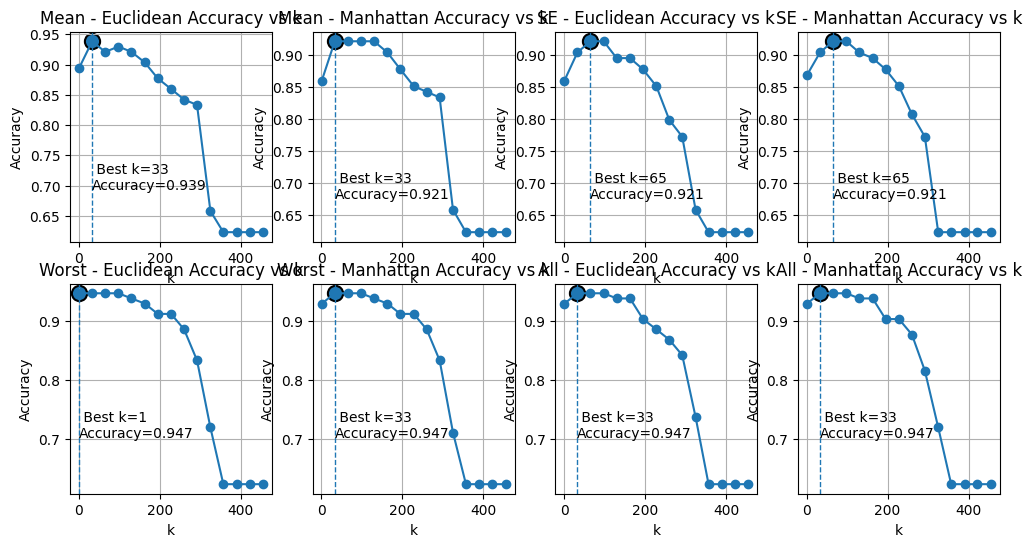

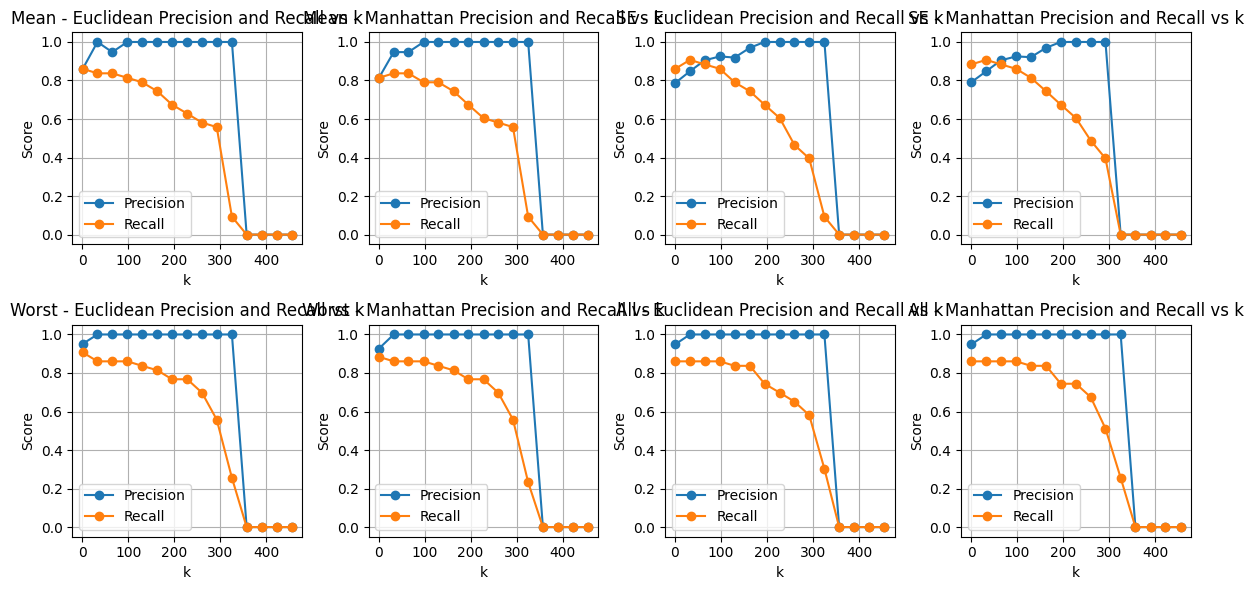

In [17]:
import matplotlib.pyplot as plt

'''
Plot the k vs Accuracy Results
'''
def plot_results(ax, df, best_k, best_accuracy, title):

    ax.plot(df['k'], df['accuracy'], marker='o', label='Accuracy')
    
    ax.scatter(best_k, best_accuracy, s=120, edgecolors='black', linewidths=1.5)
    ax.axvline(best_k, linestyle='--', linewidth=1)
    ax.text(
        best_k, best_accuracy - 0.25,
        f" Best k={best_k}\nAccuracy={best_accuracy:.3f}",
        verticalalignment='bottom',
        horizontalalignment='left'
    )
    
    ax.set_xlabel("k")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.grid(True)
    
def plot_precision_recall(ax, df, title):
    ax.plot(df["k"], df["precision"], marker='o', label="Precision")
    ax.plot(df["k"], df["recall"], marker='o', label="Recall")
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylabel("Score")
    ax.legend()
    ax.grid(True)


best_k_results = [
    (mean_euc, "Mean - Euclidean"), 
    (mean_man, "Mean - Manhattan"),
    (se_euc, "SE - Euclidean"),
    (se_man, "SE - Manhattan"),
    (worst_euc,"Worst - Euclidean"),
     (worst_man, "Worst - Manhattan"),
     (all_euc, "All - Euclidean"),
     (all_man, "All - Manhattan")]

num_plots = len(best_k_results)
rows = (num_plots + 1) // 2   # makes 2 columns
cols = 2

fig, axes = plt.subplots(cols, rows, figsize=(12, 3 * cols))
axes = axes.flatten()  # make 1D for easy indexing

fix_pr, ax_pr = plt.subplots(2, 4, figsize=(12, 6))
ax_pr = ax_pr.flatten()


for i, result in enumerate(best_k_results):
    df, best_k, best_acc, best_time = result[0]
    title = result[1]

    plot_results(
        axes[i], 
        df, 
        best_k, 
        best_acc, 
        title = title + " Accuracy vs k"
    )
    
    plot_precision_recall(
        ax_pr[i],
        df,
        title=f"{title} Precision and Recall vs k",
    )
    print(f"{title} - Best k: {best_k}, Accuracy: {best_acc:.4f}, Time: {best_time:.4f} seconds")

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()